# MODEL TRAINING & EVALUATION

#### 1. IMPORTAR LIBRERÍAS

In [1]:
# 1. IMPORTS BÁSICOS
import os
from pathlib import Path

import pandas as pd
import numpy as np

import multiprocessing
import joblib
import warnings

# modelos clásicos
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV,
    cross_val_score
)
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    make_scorer
)
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
    VotingRegressor
)
from sklearn.svm import SVR
from sklearn.linear_model import Ridge

# boosters
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# para redes (“deep learning”)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Conv1D,
    GlobalMaxPool1D,
    Dropout,
    Flatten
)
from scikeras.wrappers import KerasRegressor

# estadística y visualización
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats

#### 2. CARGAR DATASET DE FEATURES

In [2]:
# 2. CARGAR FEATURES PROCESADAS Y FILTRAR COLUMNAS
df_feat = pd.read_parquet("../data/processed/parque_solar_girasol_model_ready.parquet")

# Eliminar cualquier columna no numérica que reste al escalador
df_feat = df_feat.select_dtypes(include=[np.number])
print("Shape dataset (solo numéricos):", df_feat.shape)

Shape dataset (solo numéricos): (32037, 403)


#### 3. DIVISIÓN TRAIN/TEST TEMPORAL

In [4]:
test_days = 30
horizon   = 24
split_idx = - test_days * horizon

train = df_feat.iloc[:split_idx]
test  = df_feat.iloc[split_idx:]

X_train, y_train = train.drop(columns="generation"), train["generation"]
X_test,  y_test  = test.drop(columns="generation"),  test["generation"]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (31317, 402), Test: (720, 402)


#### 4. PIPELINE Y GRID SEARCH

#### RandomForestRegressor

In [ ]:
# 1. Calcular cuántos cores usar (un tercio de los disponibles)
total_cores = multiprocessing.cpu_count()
n_jobs_tercio = max(1, total_cores // 3)
print(f"[INFO] Cores disponibles: {total_cores}, usando n_jobs={n_jobs_tercio}")

print(f"[INFO] X_train shape: {X_train.shape}, y_train length: {len(y_train)}")

# 3. Definir el pipeline
print("[INFO] Definiendo pipeline con StandardScaler + RandomForestRegressor…")
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=n_jobs_tercio   # permite paralelizar entrenamiento del bosque
    ))
])

# 4. Definir grid de hiperparámetros
param_grid = {
    "rf__n_estimators":     [100, 200],
    "rf__max_depth":        [10, 20, None],
    "rf__min_samples_leaf": [1, 3, 5]
}
print(f"[INFO] Param grid: {param_grid}")

# 5. Configurar validación temporal
n_splits = 3
print(f"[INFO] Configurando TimeSeriesSplit con n_splits={n_splits}…")
tscv = TimeSeriesSplit(n_splits=n_splits)

# 6. Configurar GridSearchCV
print("[INFO] Creando GridSearchCV (scoring='neg_mean_absolute_error', verbose=2)…")
grid_rf = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=n_jobs_tercio,   # evalúa folds en paralelo
    verbose=2               # muestra más detalles durante el fit
)

# 7. Ajustar el modelo
print("[INFO] Iniciando búsqueda de hiperparámetros y entrenando modelo…")
grid_rf.fit(X_train, y_train)

# 8. Resultados
print(f"[RESULT] Mejores parámetros: {grid_rf.best_params_}")
print(f"[RESULT] CV MAE: {-grid_rf.best_score_:.4f}")

[INFO] Cores disponibles: 22, usando n_jobs=7
[INFO] X_train shape: (31317, 402), y_train length: 31317
[INFO] Definiendo pipeline con StandardScaler + RandomForestRegressor…
[INFO] Param grid: {'rf__n_estimators': [100, 200], 'rf__max_depth': [10, 20, None], 'rf__min_samples_leaf': [1, 3, 5]}
[INFO] Configurando TimeSeriesSplit con n_splits=3…
[INFO] Creando GridSearchCV (scoring='neg_mean_absolute_error', verbose=2)…
[INFO] Iniciando búsqueda de hiperparámetros y entrenando modelo…
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[RESULT] Mejores parámetros: {'rf__max_depth': 20, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 200}
[RESULT] CV MAE: 5.0148


#### xgboostregressor

In [8]:
# 1. Calcular cuántos cores usar (un tercio de los disponibles)
total_cores   = multiprocessing.cpu_count()
n_jobs_tercio = max(1, total_cores // 3)
print(f"[INFO] Cores disponibles: {total_cores}, usando n_jobs={n_jobs_tercio}")
print(f"[INFO] X_train shape: {X_train.shape}, y_train length: {len(y_train)}\n")

# 2. Definir el pipeline con scaler + XGBRegressor
print("[INFO] Definiendo pipeline con StandardScaler + XGBRegressor…")
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBRegressor(
        n_jobs=n_jobs_tercio,
        random_state=42,
        verbosity=0
    ))
])

# 3. Definir grid de hiperparámetros para XGB
param_grid = {
    "xgb__n_estimators":     [100, 200],
    "xgb__max_depth":        [4, 6, 10],
    "xgb__learning_rate":    [0.01, 0.1, 0.2]
}
print(f"[INFO] Param grid: {param_grid}\n")

# 4. Configurar validación temporal
n_splits = 3
print(f"[INFO] Configurando TimeSeriesSplit con n_splits={n_splits}…")
tscv = TimeSeriesSplit(n_splits=n_splits)

# 5. Configurar GridSearchCV
print("[INFO] Creando GridSearchCV (scoring='neg_mean_absolute_error', verbose=2)…")
grid_xgb = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=n_jobs_tercio,
    verbose=2
)

# 6. Ajustar el modelo
print("[INFO] Iniciando búsqueda de hiperparámetros y entrenando modelo…")
grid_xgb.fit(X_train, y_train)

# 7. Resultados
print(f"\n[RESULT] Mejores parámetros: {grid_xgb.best_params_}")
print(f"[RESULT] CV MAE: {-grid_xgb.best_score_:.4f}")


[INFO] Cores disponibles: 22, usando n_jobs=7
[INFO] X_train shape: (31317, 402), y_train length: 31317

[INFO] Definiendo pipeline con StandardScaler + XGBRegressor…
[INFO] Param grid: {'xgb__n_estimators': [100, 200], 'xgb__max_depth': [4, 6, 10], 'xgb__learning_rate': [0.01, 0.1, 0.2]}

[INFO] Configurando TimeSeriesSplit con n_splits=3…
[INFO] Creando GridSearchCV (scoring='neg_mean_absolute_error', verbose=2)…
[INFO] Iniciando búsqueda de hiperparámetros y entrenando modelo…
Fitting 3 folds for each of 18 candidates, totalling 54 fits

[RESULT] Mejores parámetros: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 4, 'xgb__n_estimators': 100}
[RESULT] CV MAE: 5.2227


##### GradientBoostingRegressor

In [7]:
# 1. Calcular cuántos cores usar (un tercio de los disponibles)
total_cores   = multiprocessing.cpu_count()
n_jobs_tercio = max(1, total_cores // 3)
print(f"[INFO] Cores disponibles: {total_cores}, usando n_jobs={n_jobs_tercio}")
print(f"[INFO] X_train shape: {X_train.shape}, y_train length: {len(y_train)}\n")

# 2. Definir el pipeline con scaler + GradientBoostingRegressor
print("[INFO] Definiendo pipeline con StandardScaler + GradientBoostingRegressor…")
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gb", GradientBoostingRegressor(
        random_state=42
    ))
])

# 3. Definir grid de hiperparámetros para GradientBoosting
param_grid = {
    "gb__n_estimators":  [100, 200],
    "gb__max_depth":     [3, 5, 7],
    "gb__learning_rate": [0.01, 0.1, 0.2],
    "gb__subsample":     [0.8, 1.0]
}
print(f"[INFO] Param grid: {param_grid}\n")

# 4. Configurar validación temporal
n_splits = 3
print(f"[INFO] Configurando TimeSeriesSplit con n_splits={n_splits}…")
tscv = TimeSeriesSplit(n_splits=n_splits)

# 5. Configurar GridSearchCV
print("[INFO] Creando GridSearchCV (scoring='neg_mean_absolute_error', verbose=2)…")
grid_gb = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=n_jobs_tercio,
    verbose=2
)

# 6. Ajustar el modelo
print("[INFO] Iniciando búsqueda de hiperparámetros y entrenando modelo…")
grid_gb.fit(X_train, y_train)

# 7. Resultados
print(f"\n[RESULT] Mejores parámetros: {grid_gb.best_params_}")
print(f"[RESULT] CV MAE: {-grid_gb.best_score_:.4f}")

[INFO] Cores disponibles: 22, usando n_jobs=7
[INFO] X_train shape: (31317, 402), y_train length: 31317

[INFO] Definiendo pipeline con StandardScaler + GradientBoostingRegressor…
[INFO] Param grid: {'gb__n_estimators': [100, 200], 'gb__max_depth': [3, 5, 7], 'gb__learning_rate': [0.01, 0.1, 0.2], 'gb__subsample': [0.8, 1.0]}

[INFO] Configurando TimeSeriesSplit con n_splits=3…
[INFO] Creando GridSearchCV (scoring='neg_mean_absolute_error', verbose=2)…
[INFO] Iniciando búsqueda de hiperparámetros y entrenando modelo…
Fitting 3 folds for each of 36 candidates, totalling 108 fits

[RESULT] Mejores parámetros: {'gb__learning_rate': 0.1, 'gb__max_depth': 3, 'gb__n_estimators': 100, 'gb__subsample': 0.8}
[RESULT] CV MAE: 5.3272


#### SVR

In [ ]:
# 1. Cálculo de cores
total_cores   = multiprocessing.cpu_count()
n_jobs_tercio = max(1, total_cores // 3)
print(f"[INFO] Cores disponibles: {total_cores}, usando n_jobs={n_jobs_tercio}")
print(f"[INFO] X_train shape: {X_train.shape}, y_train length: {len(y_train)}\n")

# 2. Pipeline con scaler + SVR
print("[INFO] Definiendo pipeline con StandardScaler + SVR…")
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

# 3. Grid de hiperparámetros para SVR
param_grid = {
    "svr__kernel":  ["rbf", "linear"],
    "svr__C":       [0.1, 1, 10],
    "svr__epsilon": [0.01, 0.1, 1]
}
print(f"[INFO] Param grid: {param_grid}\n")

# 4. Validación temporal
n_splits = 3
print(f"[INFO] Configurando TimeSeriesSplit con n_splits={n_splits}…")
tscv = TimeSeriesSplit(n_splits=n_splits)

# 5. GridSearchCV
print("[INFO] Creando GridSearchCV (scoring='neg_mean_absolute_error', verbose=2)…")
grid_svr = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=n_jobs_tercio,
    verbose=2
)

# 6. Ajuste
print("[INFO] Iniciando búsqueda de hiperparámetros y entrenando SVR…")
grid_svr.fit(X_train, y_train)

# 7. Resultados
print(f"\n[RESULT] Mejores parámetros SVR: {grid_svr.best_params_}")
print(f"[RESULT] CV MAE SVR: {-grid_svr.best_score_:.4f}")

[INFO] Cores disponibles: 22, usando n_jobs=7
[INFO] X_train shape: (31317, 402), y_train length: 31317

[INFO] Definiendo pipeline con StandardScaler + SVR…
[INFO] Param grid: {'svr__kernel': ['rbf', 'linear'], 'svr__C': [0.1, 1, 10], 'svr__epsilon': [0.01, 0.1, 1]}

[INFO] Configurando TimeSeriesSplit con n_splits=3…
[INFO] Creando GridSearchCV (scoring='neg_mean_absolute_error', verbose=2)…
[INFO] Iniciando búsqueda de hiperparámetros y entrenando SVR…
Fitting 3 folds for each of 18 candidates, totalling 54 fits


#### LSTM

In [ ]:
#### 4. LSTM CON BÚSQUEDA MANUAL DE HIPERPARÁMETROS

# 4.1. Configurar hilos de TensorFlow (1/3 de los cores)
total_cores = multiprocessing.cpu_count()
n_threads   = max(1, total_cores // 3)
print(f"[INFO] Cores disponibles: {total_cores}, usando hilos={n_threads}")
tf.config.threading.set_intra_op_parallelism_threads(n_threads)
tf.config.threading.set_inter_op_parallelism_threads(n_threads)

# 4.2. Crear secuencias (sliding window)
window_size = 24
n_features  = X_train.shape[1]
def create_sequences(X, y, window):
    Xv, yv = X.values, y.values
    n = len(Xv) - window
    Xs = np.zeros((n, window, n_features))
    ys = np.zeros(n)
    for i in range(n):
        Xs[i] = Xv[i : i + window]
        ys[i] = yv[i + window]
    return Xs, ys

print("[INFO] Generando secuencias…")
X_tr_seq, y_tr_seq = create_sequences(X_train, y_train, window_size)
X_te_seq, y_te_seq = create_sequences(X_test,  y_test,  window_size)

# 4.3. Constructor de modelo
def build_model(units, optimizer):
    m = Sequential([
        Input(shape=(window_size, n_features)),
        LSTM(units),
        Dense(1)
    ])
    m.compile(optimizer=optimizer, loss="mae")
    return m

# 4.4. Definir grilla y CV
param_grid = {
    "units":     [16, 32],
    "optimizer": ["adam", "rmsprop"],
    "batch_size":[32, 64],
    "epochs":   [10, 20]
}
tscv = TimeSeriesSplit(n_splits=3)

best_score = np.inf
best_params = None

print("\n[INFO] Iniciando búsqueda manual de hiperparámetros:")
for units in param_grid["units"]:
    for opt in param_grid["optimizer"]:
        for bs in param_grid["batch_size"]:
            for ep in param_grid["epochs"]:
                combo = dict(units=units, optimizer=opt, batch_size=bs, epochs=ep)
                fold_scores = []
                # cross-val manually
                for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_tr_seq)):
                    X_tr_f, X_val_f = X_tr_seq[tr_idx], X_tr_seq[val_idx]
                    y_tr_f, y_val_f = y_tr_seq[tr_idx], y_tr_seq[val_idx]
                    model = build_model(units, optimizer=opt)
                    model.fit(
                        X_tr_f, y_tr_f,
                        batch_size=bs,
                        epochs=ep,
                        verbose=0
                    )
                    y_pred_f = model.predict(X_val_f).ravel()
                    mae_f = mean_absolute_error(y_val_f, y_pred_f)
                    fold_scores.append(mae_f)
                mean_mae = np.mean(fold_scores)
                print(f" • {combo} → CV MAE: {mean_mae:.4f}")
                if mean_mae < best_score:
                    best_score, best_params = mean_mae, combo

print(f"\n[RESULT] Mejor combo: {best_params} con CV MAE {best_score:.4f}")

# 4.5. Entrenar modelo final con los mejores hiperparámetros
print("\n[INFO] Entrenando modelo final en todo el train set…")
final_model = build_model(
    units=best_params["units"],
    optimizer=best_params["optimizer"]
)
final_model.fit(
    X_tr_seq, y_tr_seq,
    batch_size=best_params["batch_size"],
    epochs=best_params["epochs"],
    verbose=1
)

# 4.6. Evaluación en test
print("\n[INFO] Evaluando en test…")
y_pred_te = final_model.predict(X_te_seq).ravel()
mae_te  = mean_absolute_error(y_te_seq, y_pred_te)
rmse_te = np.sqrt(mean_squared_error(y_te_seq, y_pred_te))
r2_te   = r2_score(y_te_seq, y_pred_te)

print(f"Test MAE:  {mae_te:.3f}")
print(f"Test RMSE: {rmse_te:.3f}")
print(f"Test R²:   {r2_te:.3f}")

[INFO] Cores disponibles: 22, usando hilos=7
[INFO] Generando secuencias…

[INFO] Iniciando búsqueda manual de hiperparámetros:
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 • {'units': 16, 'optimizer': 'adam', 'batch_size': 32, 'epochs': 10} → CV MAE: 14.9515
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 • {'units': 16, 'optimizer': 'adam', 'batch_size': 32, 'epochs': 20} → CV MAE: 16.7965
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 • {'units': 16, 'optimizer': 'adam', 'batch_size': 64, 'epochs': 10} → CV MAE: 22.4028
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 • {'units': 16, 'optimizer': 'adam', 'batch_size': 64, 'epochs': 20} → CV MAE: 16.9012
245/245 ━━━━━━━━━━━━━━━━━━━━

#### Conv1D

In [5]:
# --- 1. Preparar secuencias (ventana deslizante) ----------------------------
window_size = 24
n_features  = X_train.shape[1]

def create_sequences(X, y, window):
    X_vals, y_vals = X.values, y.values
    n_samples = len(X_vals) - window
    Xs = np.zeros((n_samples, window, n_features))
    ys = np.zeros(n_samples)
    for i in range(n_samples):
        Xs[i] = X_vals[i : i + window]
        ys[i] = y_vals[i + window]
    return Xs, ys

print("[INFO] Creando secuencias…")
X_train_seq, y_train_seq = create_sequences(X_train, y_train, window_size)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  window_size)
print(f" → X_train_seq: {X_train_seq.shape}, y_train_seq: {y_train_seq.shape}")
print(f" → X_test_seq:  {X_test_seq.shape},  y_test_seq:  {y_test_seq.shape}\n")


# --- 2. Definir constructor de modelo Conv1D --------------------------------
def build_cnn(filters=32, kernel_size=3, optimizer="adam"):
    model = Sequential([
        Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation="relu",
            input_shape=(window_size, n_features)
        ),
        GlobalMaxPool1D(),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss="mae")
    return model


# --- 3. Envolver en KerasRegressor (scikeras) -------------------------------
print("[INFO] Configurando KerasRegressor para Conv1D…")
cnn_reg = KerasRegressor(
    model=build_cnn,
    verbose=0
)


# --- 4. Definir grid de hiperparámetros -------------------------------------
param_grid = {
    "model__filters":     [16, 32],
    "model__kernel_size": [2, 3, 5],
    "model__optimizer":   ["adam", "rmsprop"],
    "batch_size":         [32, 64],
    "epochs":             [10, 20]
}
print(f"[INFO] Param grid Conv1D: {param_grid}\n")


# --- 5. Validación temporal -------------------------------------------------
tscv = TimeSeriesSplit(n_splits=3)
print(f"[INFO] TimeSeriesSplit(n_splits=3)\n")


# --- 6. GridSearchCV --------------------------------------------------------
print("[INFO] Iniciando GridSearchCV para Conv1D (MAE)…")
grid_cnn = GridSearchCV(
    estimator=cnn_reg,
    param_grid=param_grid,
    cv=tscv,
    scoring=make_scorer(mean_absolute_error, greater_is_better=False),
    n_jobs=1,
    verbose=2
)

# --- 7. Ajuste --------------------------------------------------------------
grid_cnn.fit(X_train_seq, y_train_seq)

# --- 8. Resultados CV -------------------------------------------------------
print(f"\n[RESULT] Mejores parámetros Conv1D: {grid_cnn.best_params_}")
print(f"[RESULT] CV MAE Conv1D: {-grid_cnn.best_score_:.4f}\n")


# --- 9. Evaluación en test -------------------------------------------------
print("[INFO] Evaluando Conv1D en test…")
best_cnn   = grid_cnn.best_estimator_
y_pred_cnn = best_cnn.predict(X_test_seq)
mae_cnn    = mean_absolute_error(y_test_seq, y_pred_cnn)
print(f"Test MAE Conv1D: {mae_cnn:.3f}")

[INFO] Creando secuencias…
 → X_train_seq: (31293, 24, 402), y_train_seq: (31293,)
 → X_test_seq:  (696, 24, 402),  y_test_seq:  (696,)

[INFO] Configurando KerasRegressor para Conv1D…
[INFO] Param grid Conv1D: {'model__filters': [16, 32], 'model__kernel_size': [2, 3, 5], 'model__optimizer': ['adam', 'rmsprop'], 'batch_size': [32, 64], 'epochs': [10, 20]}

[INFO] TimeSeriesSplit(n_splits=3)

[INFO] Iniciando GridSearchCV para Conv1D (MAE)…
Fitting 3 folds for each of 48 candidates, totalling 144 fits


c:\Users\ferna\Documents\Desktop\11 - Masters\00 - Master AI\99 - Proyecto Final\energy-generation-prediction-dashboard\my_environment\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=32, epochs=10, model__filters=16, model__kernel_size=2, model__optimizer=adam; total time=   5.7s


c:\Users\ferna\Documents\Desktop\11 - Masters\00 - Master AI\99 - Proyecto Final\energy-generation-prediction-dashboard\my_environment\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=32, epochs=10, model__filters=16, model__kernel_size=2, model__optimizer=adam; total time=  10.3s


...

[CV] END batch_size=64, epochs=20, model__filters=32, model__kernel_size=5, model__optimizer=rmsprop; total time=  16.6s


c:\Users\ferna\Documents\Desktop\11 - Masters\00 - Master AI\99 - Proyecto Final\energy-generation-prediction-dashboard\my_environment\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=64, epochs=20, model__filters=32, model__kernel_size=5, model__optimizer=rmsprop; total time=  25.5s


c:\Users\ferna\Documents\Desktop\11 - Masters\00 - Master AI\99 - Proyecto Final\energy-generation-prediction-dashboard\my_environment\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[RESULT] Mejores parámetros Conv1D: {'batch_size': 32, 'epochs': 20, 'model__filters': 16, 'model__kernel_size': 5, 'model__optimizer': 'rmsprop'}
[RESULT] CV MAE Conv1D: 25.5290

[INFO] Evaluando Conv1D en test…
Test MAE Conv1D: 29.809


#### 5. EVALUACIÓN EN TEST

Test MAE:  6.435
Test RMSE: 11.588
Test R²:   0.900


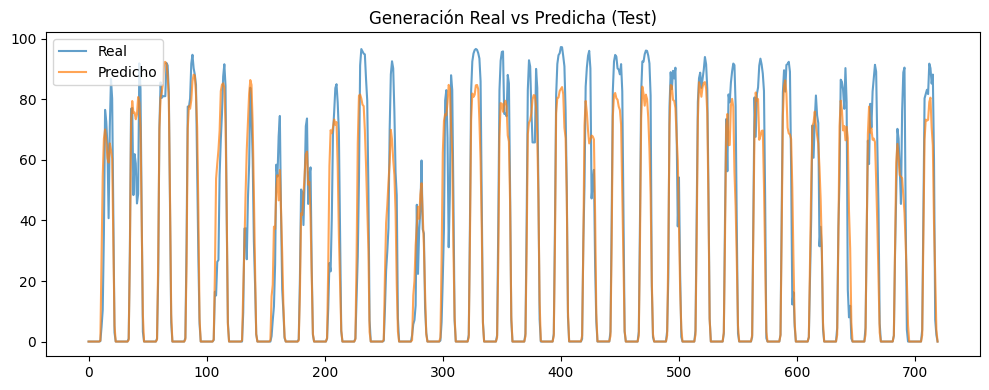

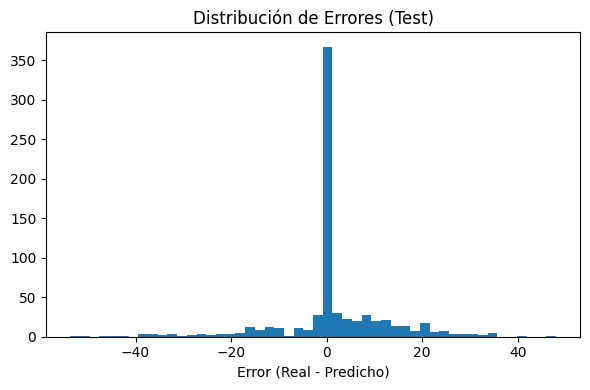

In [14]:
best_model = grid_rf.best_estimator_
y_pred     = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)             # devuelve el MSE
rmse = np.sqrt(mse)                                   # RMSE
r2   = r2_score(y_test, y_pred)

print(f"Test MAE:  {mae:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²:   {r2:.3f}")

# Gráfica Real vs Predicha
plt.figure(figsize=(10,4))
plt.plot(y_test.values, label="Real", alpha=0.7)
plt.plot(y_pred,           label="Predicho", alpha=0.7)
plt.title("Generación Real vs Predicha (Test)")
plt.legend()
plt.tight_layout()
plt.show()

# Histograma de residuos
plt.figure(figsize=(6,4))
plt.hist(y_test.values - y_pred, bins=50)
plt.title("Distribución de Errores (Test)")
plt.xlabel("Error (Real - Predicho)")
plt.tight_layout()
plt.show()

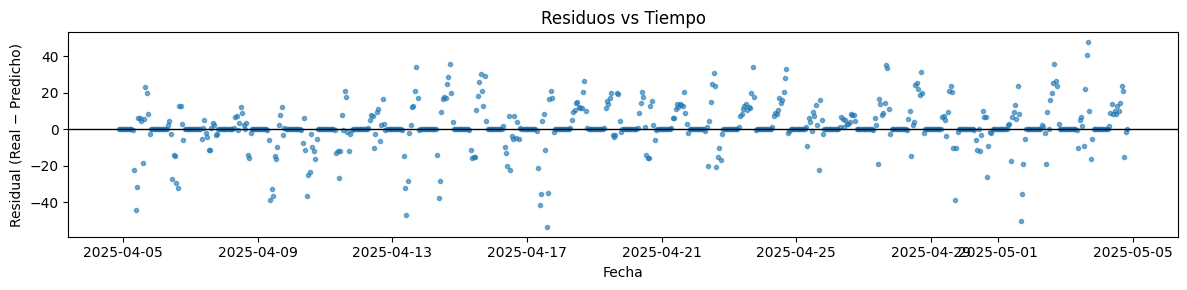

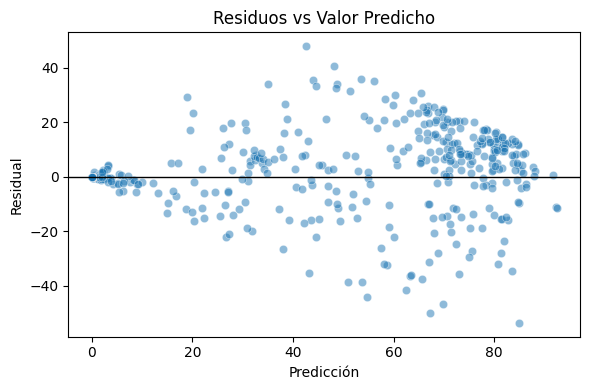

<Figure size 600x400 with 0 Axes>

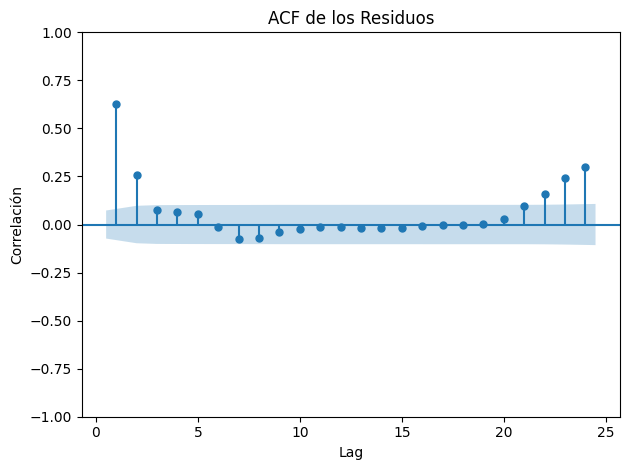

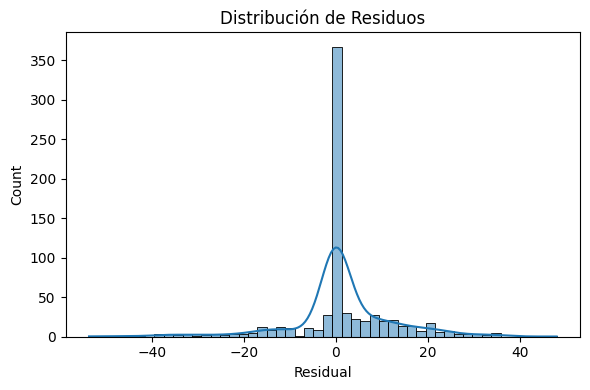

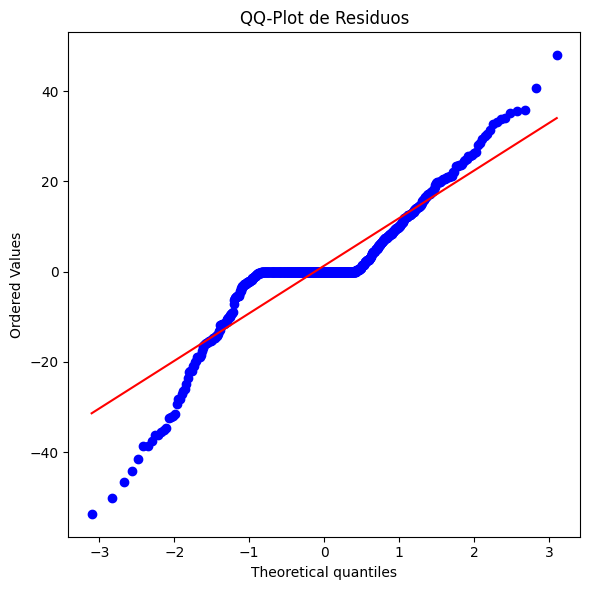

In [15]:
# 1. Calcular predicciones y residuos
y_pred = best_model.predict(X_test)
residuals = y_test.values - y_pred
idx = y_test.index  # Índice temporal si existe

# 2. Residuos vs Tiempo
plt.figure(figsize=(12,3))
plt.plot(idx, residuals, marker='.', linestyle='none', alpha=0.6)
plt.axhline(0, color='k', linewidth=1)
plt.title("Residuos vs Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Residual (Real − Predicho)")
plt.tight_layout()
plt.show()

# 3. Residual vs Predicho
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='k', linewidth=1)
plt.title("Residuos vs Valor Predicho")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

# 4. Autocorrelación de Residuos (ACF)
plt.figure(figsize=(6,4))
plot_acf(residuals, lags=24, zero=False)
plt.title("ACF de los Residuos")
plt.xlabel("Lag")
plt.ylabel("Correlación")
plt.tight_layout()
plt.show()

# 5. Histograma + KDE de residuos
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribución de Residuos")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

# 6. QQ-Plot (Normalidad)
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot de Residuos")
plt.tight_layout()
plt.show()

#### 6. GUARDAR MODELO PARA PRODUCCIÓN

In [16]:
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/solar_generation_model.joblib")
print("Modelo guardado en: models/solar_generation_model.joblib")

Modelo guardado en: models/solar_generation_model.joblib
